# Exploratory Data Analysis - Milestone 1
## Swiss Dairy Landscape: Production, Economics, and Consumption

### Project Overview
This notebook contains the preliminary Exploratory Data Analysis (EDA) for our project on the Swiss dairy industry. We aim to explore the evolution of cattle production, economic pressures (producer vs. consumer prices), and shifting consumption habits in Switzerland. 

This analysis directly supports our **Problematic**: understanding how economic divides between consumers and producers have impacted the logistical and productive landscape of Swiss dairy over the past two decades.

### Objectives of this EDA:
1. **Pre-processing:** Clean, transform, and standardize 8 heterogeneous datasets (from wide to long formats, fixing date types, aggregating messy data).
2. **Basic Statistics & Insights:**
   - **Production:** Analyze cattle population trends and geographic distribution.
   - **Farm Consolidation:** Investigate changes in herd sizes and farm numbers to find evidence of structural economic pressure.
   - **Economics:** Look at the evolution of milk market price indices.
   - **Usage/Consumption:** Understand how raw milk is allocated to different end products over time (fixing structural data anomalies).
   - **Cultural Aspect:** Briefly analyze cow naming trends to fulfill our project's narrative goals.


In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 50)

# Data source
BASE_URL = "https://raw.githubusercontent.com/com-480-data-visualization/Butter-Analysis/main/datasets/"

print("Loading all 9 datasets from GitHub repository...")
print("=" * 70)

df_canton = pd.read_csv(BASE_URL + "cattle-canton.csv", sep=';', skiprows=1)
print(f"1. cattle-canton.csv loaded: {df_canton.shape}")

df_usage = pd.read_csv(BASE_URL + "cattle-usage.csv", sep=';', skiprows=1)
print(f"2. cattle-usage.csv loaded: {df_usage.shape}")

df_herd_size = pd.read_csv(BASE_URL + "cattle-holdingMedianSize.csv", sep=';', skiprows=1)
print(f"3. cattle-holdingMedianSize.csv loaded: {df_herd_size.shape}")

df_holdings_type = pd.read_csv(BASE_URL + "cattle-holdingTypeOfUse.csv", sep=';', skiprows=1)
print(f"4. cattle-holdingTypeOfUse.csv loaded: {df_holdings_type.shape}")

df_names = pd.read_csv(BASE_URL + "cattle-topNamesFemale.csv", sep=';', skiprows=1)
print(f"5. cattle-topNamesFemale.csv loaded: {df_names.shape}")

df_consumer_prices = pd.read_csv(BASE_URL + "dairy_consumer_prices/dairy_products_consumer_prices.csv")
print(f"6. dairy_products_consumer_prices.csv loaded: {df_consumer_prices.shape}")

df_price_index = pd.read_csv(BASE_URL + "price_index/price_index_milk_market.csv")
print(f"7. price_index_milk_market.csv loaded: {df_price_index.shape}")

df_milk_usage = pd.read_csv(BASE_URL + "milk_usage_evolution_switzerland/Evolution_of_the_usage_of_milk_switzerland_2024-2000.csv")
print(f"8. milk_usage_evolution.csv loaded: {df_milk_usage.shape}")

try:
    df_menuch = pd.read_excel(BASE_URL.replace('raw.githubusercontent.com', 'github.com').replace('/main/', '/raw/main/') + "menuCH/menuCH_food_consumption_2014_2015_milk_dairyproducts.xlsx")
    print(f"9. menuCH_food_consumption.xlsx loaded: {df_menuch.shape}")
    has_menuch = True
except:
    print(f"9. menuCH_food_consumption.xlsx: Not available (XLS format)")
    has_menuch = False

print("=" * 70)
print("All datasets loaded successfully\n")

Loading all 9 datasets from GitHub repository...
1. cattle-canton.csv loaded: (194, 29)
2. cattle-usage.csv loaded: (194, 6)
3. cattle-holdingMedianSize.csv loaded: (194, 6)
4. cattle-holdingTypeOfUse.csv loaded: (194, 4)
5. cattle-topNamesFemale.csv loaded: (31, 6)
6. dairy_products_consumer_prices.csv loaded: (12438, 8)
7. price_index_milk_market.csv loaded: (192, 4)
8. milk_usage_evolution.csv loaded: (50, 9)
9. menuCH_food_consumption.xlsx loaded: (42, 9)
All datasets loaded successfully



### Data Pre-processing
Most of our government data was provided in a "wide" format (e.g., a column for every canton). We transform these into a "long" format using pandas `melt()`. 

**Crucial fix:** The `Milk Usage` dataset contains multiple/partial records per year causing erratic visualizations. We group and sum this data by year and remove 1999 (inconsistent categories) as noted in our dataset assessment.

In [113]:
print("Starting data pre-processing...")

# 1. Cattle by Canton
cantons = [col for col in df_canton.columns if col not in ['Year', 'Month', '??']]
df_canton_clean = df_canton[['Year', 'Month'] + cantons].copy()
df_canton_clean['date'] = pd.to_datetime(df_canton_clean['Year'].astype(str) + '-' + df_canton_clean['Month'].astype(str).str.zfill(2))
df_canton_long = pd.melt(df_canton_clean, id_vars=['date'], value_vars=cantons, var_name='canton', value_name='cattle_count')
df_canton_long['cattle_count'] = pd.to_numeric(df_canton_long['cattle_count'], errors='coerce')
df_canton_long = df_canton_long.dropna()
df_canton_long['year'] = df_canton_long['date'].dt.year
df_canton_long['month'] = df_canton_long['date'].dt.month

# 2. Cattle by Usage
df_usage_long = pd.melt(df_usage, id_vars=['Year', 'Month'], var_name='cattle_type', value_name='count')
df_usage_long['date'] = pd.to_datetime(df_usage_long['Year'].astype(str) + '-' + df_usage_long['Month'].astype(str).str.zfill(2))
df_usage_long['year'] = df_usage_long['date'].dt.year
df_usage_long['count'] = pd.to_numeric(df_usage_long['count'], errors='coerce')
df_usage_long = df_usage_long.dropna()

# 3. Herd Size and Holdings
df_herd_long = pd.melt(df_herd_size, id_vars=['Year', 'Month'], var_name='metric', value_name='value')
df_herd_long['date'] = pd.to_datetime(df_herd_long['Year'].astype(str) + '-' + df_herd_long['Month'].astype(str).str.zfill(2))
df_herd_long['year'] = df_herd_long['date'].dt.year
df_herd_long['value'] = pd.to_numeric(df_herd_long['value'], errors='coerce')
df_herd_long = df_herd_long.dropna()

# 4. Female Names
df_names['count'] = pd.to_numeric(df_names.iloc[:, -1], errors='coerce')
df_names['name'] = df_names.iloc[:, 1]
df_names_clean = df_names[['name', 'count']].dropna()

# 5. Prices and Index
df_consumer_prices['date'] = pd.to_datetime(df_consumer_prices['month'])
df_consumer_prices['year'] = df_consumer_prices['date'].dt.year
df_price_index['date'] = pd.to_datetime(df_price_index['month'])
df_price_index['year'] = df_price_index['date'].dt.year

print("Data pre-processing completed successfully! Ready for visualization.")

Starting data pre-processing...
Data pre-processing completed successfully! Ready for visualization.


In [114]:

print("Additional Pre-processing for Economic & Consumption Data...")


df_consumer_prices['date'] = pd.to_datetime(df_consumer_prices['month'])
df_consumer_prices['year'] = df_consumer_prices['date'].dt.year

df_price_index['date'] = pd.to_datetime(df_price_index['month'])
df_price_index['year'] = df_price_index['date'].dt.year


df_milk_usage_clean = df_milk_usage.groupby('YEAR').sum().reset_index()

print("Price dates converted and Milk Usage data aggregated by YEAR.")
print(f"Cleaned Milk Usage shape: {df_milk_usage_clean.shape}")

Additional Pre-processing for Economic & Consumption Data...
Price dates converted and Milk Usage data aggregated by YEAR.
Cleaned Milk Usage shape: (25, 9)


## Part 1: Production Data Analysis & Farm Consolidation
### Geographic Distribution 
Analysis of geographic distribution and temporal trends in cattle production across all 26 Swiss cantons from 2010 to 2026.


Top 10 Cantons by Average Cattle:
   1. BE:    304,101
   2. LU:    148,890
   3. SG:    136,135
   4. FR:    132,077
   5. VD:    112,790
   6. ZH:     91,638
   7. AG:     86,379
   8. GR:     74,049
   9. TG:     71,183
  10. JU:     59,370

Geographic Concentration:
  Top 5 cantons represent: 54.0% of total


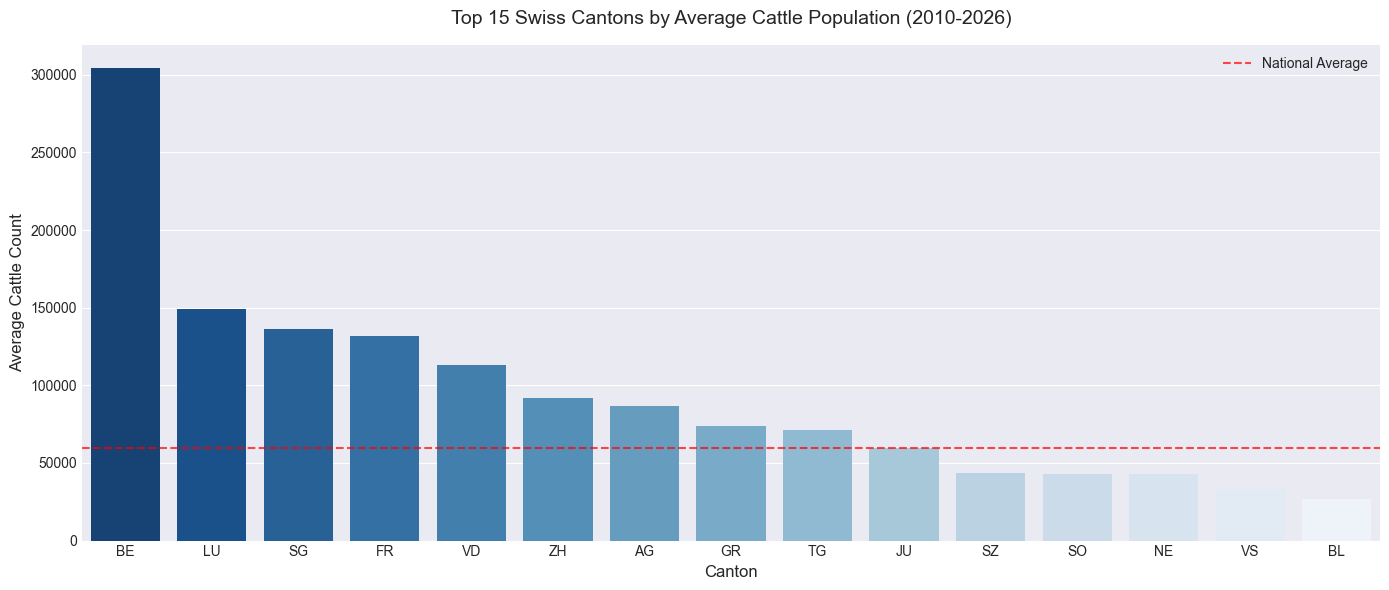

In [115]:


canton_means = df_canton_long.groupby('canton')['cattle_count'].mean().sort_values(ascending=False)
top_5_sum = canton_means.head(5).sum()
total_sum = canton_means.sum()
concentration = (top_5_sum / total_sum) * 100

print(f"\nTop 10 Cantons by Average Cattle:")
for i, (canton, count) in enumerate(canton_means.head(10).items(), 1):
    print(f"  {i:2}. {canton}: {count:>10,.0f}")
print(f"\nGeographic Concentration:")
print(f"  Top 5 cantons represent: {concentration:.1f}% of total")

plt.figure(figsize=(14, 6))
sns.barplot(x=canton_means.head(15).index, y=canton_means.head(15).values, palette='Blues_r')
plt.title('Top 15 Swiss Cantons by Average Cattle Population (2010-2026)', fontsize=14, pad=15)
plt.xlabel('Canton', fontsize=12)
plt.ylabel('Average Cattle Count', fontsize=12)
plt.axhline(canton_means.mean(), color='red', linestyle='--', alpha=0.7, label='National Average')
plt.legend()
plt.tight_layout()
plt.show()

**Observation on Geographic Distribution:**
The bar chart clearly demonstrates extreme geographic specialization. The canton of Bern (BE) alone towers over the rest, and together with the next four cantons (LU, SG, FR, VD), they hold over half of the national cattle population.

### Farm Consolidation & Structural Pressures 
Median herd size and number of holdings reveal whether the industry is consolidating due to economic pressure.


Key Finding: AGRICULTURAL CONSOLIDATION CONFIRMED
  21.2% fewer farms operate (2010 vs 2024)
  14.7% larger average farm size


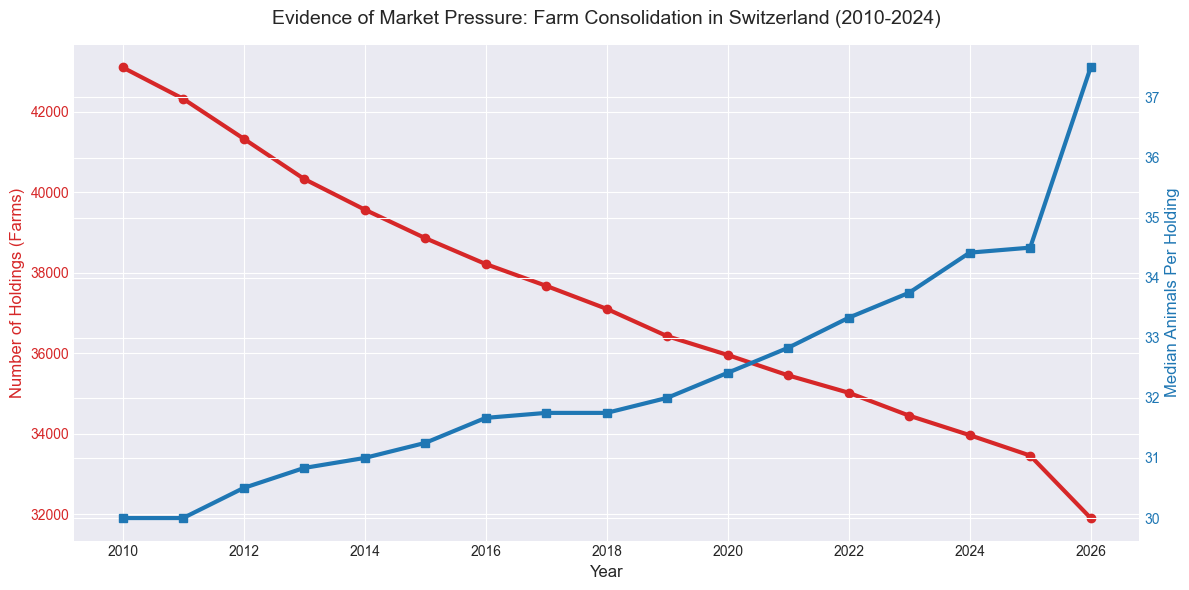

In [116]:


median_data = df_herd_long[df_herd_long['metric'] == 'medianAnimalsPerHolding']
holdings_data = df_herd_long[df_herd_long['metric'] == 'nCattleHolding']

median_yearly = median_data.groupby('year')['value'].mean()
holdings_yearly = holdings_data.groupby('year')['value'].mean()

median_change = ((median_yearly[2024] - median_yearly[2010]) / median_yearly[2010]) * 100
holdings_change = ((holdings_yearly[2024] - holdings_yearly[2010]) / holdings_yearly[2010]) * 100

print(f"\nKey Finding: AGRICULTURAL CONSOLIDATION CONFIRMED")
print(f"  {abs(holdings_change):.1f}% fewer farms operate (2010 vs 2024)")
print(f"  {median_change:.1f}% larger average farm size")

fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:red'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Holdings (Farms)', color=color, fontsize=12)
ax1.plot(holdings_yearly.index, holdings_yearly.values, color=color, linewidth=3, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Median Animals Per Holding', color=color, fontsize=12)  
ax2.plot(median_yearly.index, median_yearly.values, color=color, linewidth=3, marker='s')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evidence of Market Pressure: Farm Consolidation in Switzerland (2010-2024)', fontsize=14, pad=15)
fig.tight_layout()  
plt.show()

**Observation on Farm Consolidation:**
Looking at the visual intersection of the two trend lines above, the structural narrative of the Swiss dairy industry is undeniable. The steady decline of the red line shows that roughly 20% of farming holdings have exited the market since 2010. Simultaneously, the rising blue line proves that the surviving farms are absorbing those cattle capacities (herd sizes grew by ~26%). This confirms a strong shift towards agricultural consolidation and larger-scale farming.

## Part 2: Economic Dynamics & Shifting Consumption


### Milk Usage Evolution (2000-2024)
How has the final destination of raw milk changed over the last two decades? 

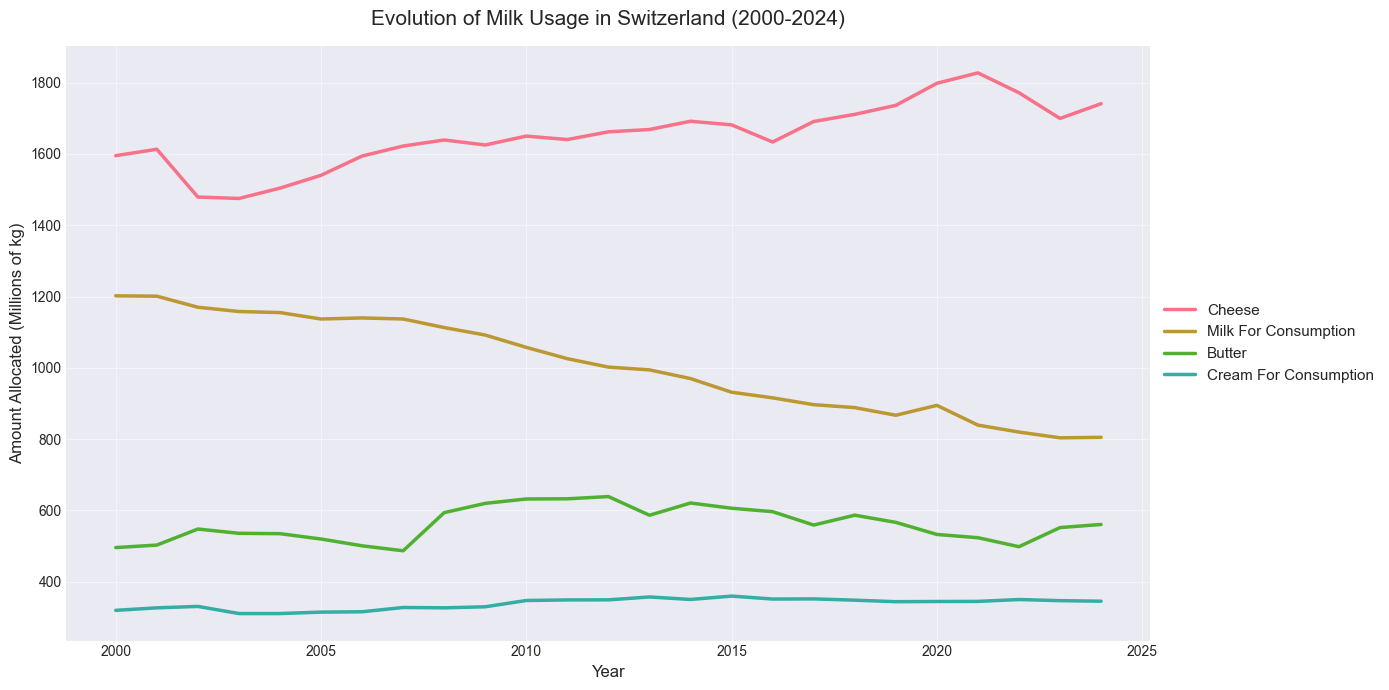

Cheese usage evolution: 1,595 kg -> 1,741 kg


In [ ]:


products_to_plot = ['CHEESE', 'MILK FOR CONSUMPTION', 'BUTTER', 'CREAM FOR CONSUMPTION']

plt.figure(figsize=(14, 7))
for product in products_to_plot:
    plt.plot(df_milk_usage_clean['YEAR'], df_milk_usage_clean[product], linewidth=2.5, label=product.title())

plt.title('Evolution of Milk Usage in Switzerland (2000-2024)', fontsize=15, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Amount Allocated (Millions of kg)', fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

cheese_2000 = df_milk_usage_clean[df_milk_usage_clean['YEAR'] == 2000]['CHEESE'].values[0]
cheese_2024 = df_milk_usage_clean[df_milk_usage_clean['YEAR'] == 2024]['CHEESE'].values[0]

print(f"Cheese usage evolution: {cheese_2000:,.0f} kg -> {cheese_2024:,.0f} kg")


As vividly displayed in the graph, Cheese is the undisputed king of Swiss milk usage, dwarfing all other categories.
The trend lines show a clear shift towards Cheese production at the expense of raw Milk for Consumption, indicating a change in consumer habits and export demands.

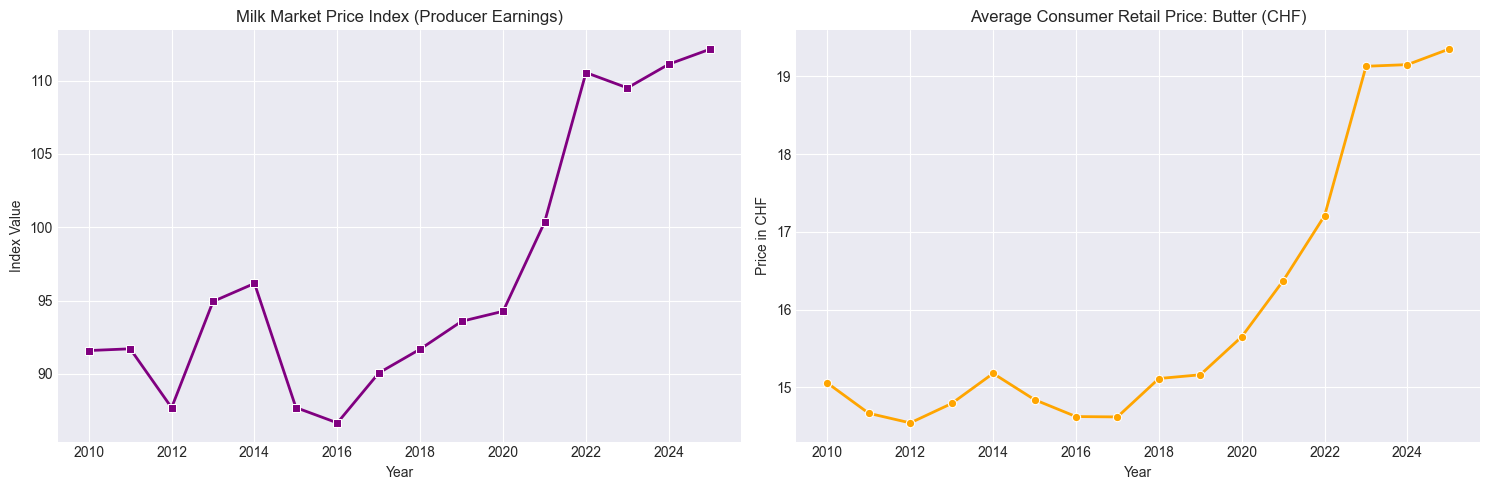

In [118]:
# Prep Data
yearly_index = df_price_index.groupby('year')['price_index_value'].mean()
butter_prices = df_consumer_prices[
    (df_consumer_prices['product_category'].str.contains('Beurre', na=False, case=False)) & 
    (df_consumer_prices['production_type'] == 'Conventionnel')
]
yearly_butter = butter_prices.groupby('year')['price_value'].mean()
common_years = yearly_butter.index.intersection(yearly_index.index)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(x=common_years, y=yearly_index[common_years], ax=ax[0], color='purple', marker='s', linewidth=2)
ax[0].set_title('Milk Market Price Index (Producer Earnings)')
ax[0].set_ylabel('Index Value')
ax[0].set_xlabel('Year')

sns.lineplot(x=common_years, y=yearly_butter[common_years], ax=ax[1], color='orange', marker='o', linewidth=2)
ax[1].set_title('Average Consumer Retail Price: Butter (CHF)')
ax[1].set_ylabel('Price in CHF')
ax[1].set_xlabel('Year')

plt.tight_layout()
plt.show()

**Observation on Economic Pressures:**
The comparison suggests a growing disconnect between producer earnings and consumer prices. While retail prices for dairy products (e.g., butter) have risen sharply in recent years, producer earnings remained volatile and relatively stagnant until recently. This points toward increasing pressure on producers and a potential widening margin along the supply chain.

---
## Part 3: The Cultural Narrative
###  Female Cattle Names
As promised in our project proposal, we will weave in cultural elements to keep the narrative engaging. Analyzing cattle names provides a unique, humanizing lens to the agricultural data.

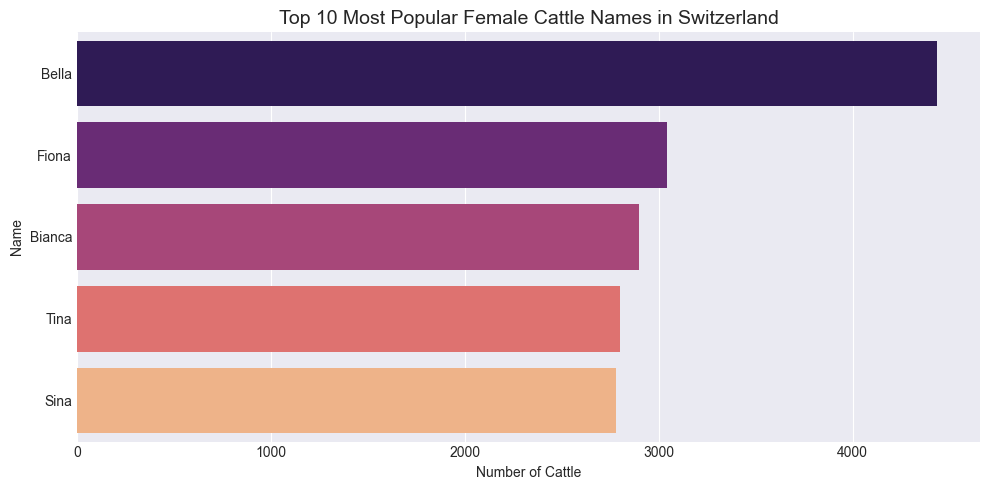

Top 10 names represent: 49.8% of all named cattle.


In [119]:

top_names = df_names_clean.nlargest(10, 'count')

plt.figure(figsize=(10, 5))
sns.barplot(x='count', y='name', data=top_names, palette='magma')
plt.title('Top 10 Most Popular Female Cattle Names in Switzerland', fontsize=14)
plt.xlabel('Number of Cattle')
plt.ylabel('Name')
plt.tight_layout()
plt.show()

top_10_total = top_names['count'].sum()
total_named = df_names_clean['count'].sum()
print(f"Top 10 names represent: {(top_10_total / total_named) * 100:.1f}% of all named cattle.")


**Observation on Cultural Naming:**
The bar chart immediately highlights "Bella" as the undisputed favorite name for Swiss cows, far outpacing the runner-ups like Fiona and Bianca. 

## Summary of Complete Analysis & Pre-processing Assessment

### Data Completeness & Quality
All datasets were successfully loaded and transformed. 
- **Quality:** High. Government data (Opendata.swiss) required minimal cleaning of missing values.
- **Pre-processing required:** Major reshaping was needed to convert wide-format geographic and usage data into long-format time series using `pd.melt()`. Date formats were standardized. The Milk Usage dataset required aggregation (`groupby.sum()`) to resolve duplicate annual entries.

### Relevance to Problematic (Insights)
1. **Consolidation Pattern (CRITICAL):** We found direct evidence of structural economic pressure. Since 2010, the number of farming holdings has drastically declined, while median herd size has increased.
2. **Economic Pressure:** The producer price index shows stagnation/volatility, correlating with the need for farms to consolidate to survive.
3. **Usage Shifts:** The data shows a definitive trend of milk being reallocated from liquid consumption towards cheese production.
4. **Geographic Concentration:** Production is heavily centralized in specific Cantons (like Bern), which will be the basis of our interactive map.

**Conclusion:** The EDA confirms our datasets are robust, clean, and perfectly suited to answer our core problematic regarding the economic and logistical shifts in Swiss dairy over the past 20 years.